In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from tree.tree import Tree
from tree_tensor.tree_tensor_torch import TreeBasedTensor
from tree_cross.tree_cross_torch import TreeCross
from tree.tree_util import linear_tupletree, balanced_binary_tupletree, weighted_binary_tupletree

rng = np.random.default_rng()

In [2]:
Nx = 100    # spatial resolution
Ny = 5       # parameter resolution
n_a_param = 20 # number of parameters for diffusion coeff
n_param = n_a_param
offset = 1   # parameter mean
var = 4       # 'variance' of the parameters
tol = 1e-5
N_MC = 500

In [3]:
class diffusion_coeff:
  def __init__(self, Nx, Ny, offset, var):
    self.Nx = Nx
    self.Ny = Ny
    self.offset = offset
    self.var = var

  def __call__(self, X):
    c = np.full(len(X), self.offset,dtype=float)
    for i, x in enumerate(X):
      k = np.arange(1,len(x)-1)
      # k = k[k != 7]
      c[i] += np.sum(k**-2. * np.sin(np.pi*k*x[0]/(self.Nx-1)) \
                      * (x[k]/(self.Ny-1) - 0.5) * self.var)
    return np.exp(c)
  
def RMS(x, **kwargs):
  return np.sqrt(np.mean(np.square(x), **kwargs))
  
def err_MC(tensor, cfun, N_MC=500):
  N_MC = 500
  errs = np.zeros(N_MC)

  for i in range(N_MC):
    # eval TT-approx of coeff
    y = rng.integers(0, Ny, n_a_param)
    C_eval = np.ravel(tensor[:, *y])

    X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
    C_true = cfun(X)

    errs[i] = RMS(C_eval-C_true)

  return errs

In [4]:
cfun = diffusion_coeff(Nx, Ny, offset, var)

param_shape = tuple([Ny] * n_param)

# tree = Tree.from_tupletree((0,(1,((2,3), (4,(5,6))))))
# tree = Tree.from_tupletree(linear_tupletree(n_a_param))
tree = Tree.from_tupletree(balanced_binary_tupletree(n_a_param))

tree.print()
C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

[40] (root) 
 + [0] (dim 0)
 + [39] 
    + [19] 
    |  + [9] 
    |  |  + [3] 
    |  |  |  + [1] (dim 1)
    |  |  |  + [2] (dim 2)
    |  |  + [8] 
    |  |     + [4] (dim 3)
    |  |     + [7] 
    |  |        + [5] (dim 4)
    |  |        + [6] (dim 5)
    |  + [18] 
    |     + [12] 
    |     |  + [10] (dim 6)
    |     |  + [11] (dim 7)
    |     + [17] 
    |        + [13] (dim 8)
    |        + [16] 
    |           + [14] (dim 9)
    |           + [15] (dim 10)
    + [38] 
       + [28] 
       |  + [22] 
       |  |  + [20] (dim 11)
       |  |  + [21] (dim 12)
       |  + [27] 
       |     + [23] (dim 13)
       |     + [26] 
       |        + [24] (dim 14)
       |        + [25] (dim 15)
       + [37] 
          + [31] 
          |  + [29] (dim 16)
          |  + [30] (dim 17)
          + [36] 
             + [32] (dim 18)
             + [35] 
                + [33] (dim 19)
                + [34] (dim 20)



In [5]:
res = {}
C_a_test = TreeBasedTensor.randn(tree, (Nx,) + param_shape, 2)
for kickrank in []:
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, 2)
  res[kickrank] = {'n_eval':[], 'err':[]}
  n_eval_over_iter = []
  cross = TreeCross(C_a)
  iter = 0
  while cross.n_eval < 1e6 and iter < 20:
    cross.run(cfun, n_iter=1, eps=tol, kickrank=kickrank, verbose=1)
    # C_a.print()

    C_a_test = C_a.copy()
    C_a_test.round(tol=tol)
    # C_a_test.print()
    errs = err_MC(C_a_test, cfun)

    res[kickrank]['err'] += [RMS(errs)]
    res[kickrank]['n_eval'] += [cross.n_eval]
    iter += 1

C_a_test.print()

Tree tensor with shape (100, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5)
[40] root ranks=torch.Size([2, 2, 1])
 + [0] dim 0 of size 100
 + [39] ranks=torch.Size([2, 2, 2])
    + [19] ranks=torch.Size([2, 2, 2])
    |  + [9] ranks=torch.Size([2, 2, 2])
    |  |  + [3] ranks=torch.Size([2, 2, 2])
    |  |  |  + [1] dim 1 of size 5
    |  |  |  + [2] dim 2 of size 5
    |  |  + [8] ranks=torch.Size([2, 2, 2])
    |  |     + [4] dim 3 of size 5
    |  |     + [7] ranks=torch.Size([2, 2, 2])
    |  |        + [5] dim 4 of size 5
    |  |        + [6] dim 5 of size 5
    |  + [18] ranks=torch.Size([2, 2, 2])
    |     + [12] ranks=torch.Size([2, 2, 2])
    |     |  + [10] dim 6 of size 5
    |     |  + [11] dim 7 of size 5
    |     + [17] ranks=torch.Size([2, 2, 2])
    |        + [13] dim 8 of size 5
    |        + [16] ranks=torch.Size([2, 2, 2])
    |           + [14] dim 9 of size 5
    |           + [15] dim 10 of size 5
    + [38] ranks=torch.Size([2, 2, 2])
       + [

/tmp/ipykernel_3037986/3024725004.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


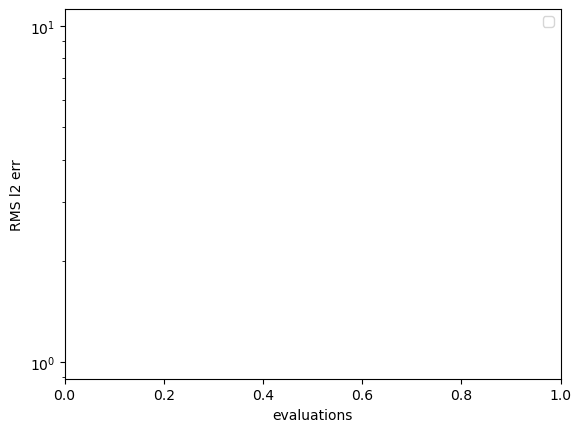

In [6]:
fig, ax = plt.subplots()
for kickrank, data in res.items():
  ax.plot(data['n_eval'], data['err'], marker='o', ms=3, label=f'kickrank={kickrank}')
ax.set_yscale('log')
ax.set_ylabel('RMS l2 err')
ax.set_xlabel('evaluations')
ax.legend()

/tmp/ipykernel_3037986/1627269564.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


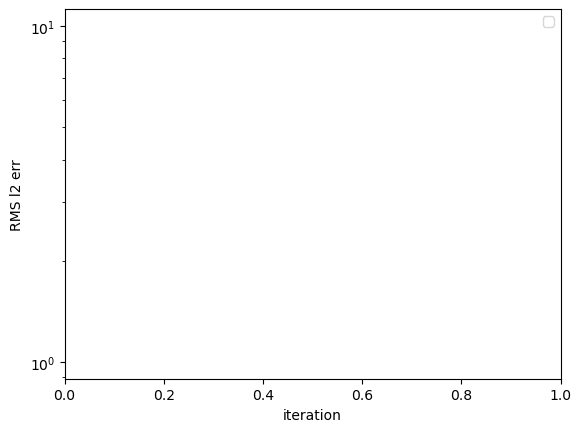

In [7]:
fig, ax = plt.subplots()
for kickrank, data in res.items():
  ax.plot(data['err'], marker='o', ms=1, label=f'kickrank={kickrank}')
ax.set_yscale('log')
ax.set_ylabel('RMS l2 err')
ax.set_xlabel('iteration')
ax.legend()

RMS l2 err = 5.66e+04


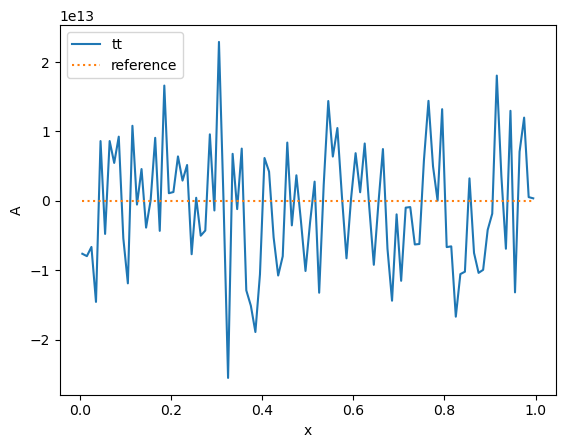

In [8]:
errs = err_MC(C_a_test, cfun, N_MC=N_MC)

print(f'RMS l2 err = {RMS(errs):.2e}')

fig, ax = plt.subplots()
y = rng.integers(0, Ny, n_a_param)
C_eval = np.ravel(C_a[:, *y])
X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
C_true = cfun(X)

x = (np.arange(0, Nx) + .5) / Nx
ax.plot(x, C_eval, label='tt')
ax.plot(x, C_true, ls='dotted', label="reference")
ax.set_xlabel('x')
ax.set_ylabel('A')
ax.legend()

In [19]:
niter = 15
eps = 1e-4
kickrank = 5
runs = 10

res = {}

trees = {
  'linear': Tree.from_tupletree(linear_tupletree(n_param)),
  'balanced': Tree.from_tupletree(balanced_binary_tupletree(n_param)),
  'weighted': Tree.from_tupletree(weighted_binary_tupletree(n_param, (np.arange(n_param)+1)**-2.))
}

In [20]:
for tree_type, tree in trees.items():
  print('type: ', tree_type)
  stats = {'errs':[], 'sizes':[], 'evals':[]}
  for run in range(runs):
    print(f'\r run {run}', end='')
    C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, 2)
    errs = np.zeros(niter)
    evals = np.zeros(niter)
    sizes = np.zeros(niter)
    cross = TreeCross(C_a)
    for iter in range(niter):
      cross.run(cfun, n_iter=1, eps=eps, kickrank=kickrank, verbose=False, force_init=False)
      C_test = TreeBasedTensor(C_a)
      C_test.round(tol=tol)
      errs[iter] = np.sqrt(np.mean(np.square(err_MC(C_test, cfun, N_MC=N_MC))))
      evals[iter] = cross.n_eval
      sizes[iter] = C_test.sparse_size

    stats['errs'] += [errs]
    stats['evals'] += [evals]
    stats['sizes'] += [sizes]
  print()

  res[tree_type] = stats

type:  linear
 run 9
type:  balanced
 run 9
type:  weighted
 run 9


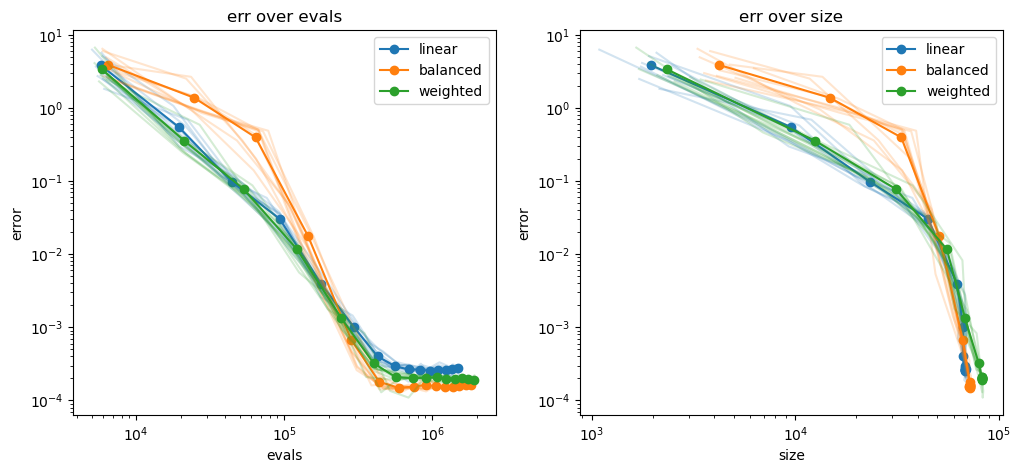

In [21]:
fig, axs = plt.subplots(1,2, figsize=(12,5))

axs[0].set_title('err over evals')
axs[0].set_xlabel('evals')
axs[1].set_title('err over size')
axs[1].set_xlabel('size')
for tree_type in trees.keys():
  evals = np.array(res[tree_type]['evals'])
  sizes = np.array(res[tree_type]['sizes'])
  errs = np.array(res[tree_type]['errs'])
  p = axs[0].plot(np.mean(evals, axis=0), np.mean(errs, axis=0), marker='o', label=tree_type)
  # axs[0].fill_between(np.mean(evals, axis=0), np.min(errs, axis=0), np.max(errs, axis=0), alpha=.5)
  axs[0].plot(evals.T, errs.T, alpha=.2, c = p[0].get_color())
  axs[1].plot(np.mean(sizes, axis=0), np.mean(errs, axis=0), marker='o', label=tree_type)
  # axs[1].fill_between(np.mean(sizes, axis=0), np.min(errs, axis=0), np.max(errs, axis=0), alpha=.5)
  axs[1].plot(sizes.T, errs.T, alpha=.2, c = p[0].get_color())

for ax in axs:
  ax.legend()
  ax.set_xscale('log')
  ax.set_yscale('log')
  ax.set_ylabel('error')